# Scattering covariances in the DES footprint

`somapy.harmonic` has classes that compute directional scattering covariances (similar to
[s2scat](https://github.com/astro-informatics/s2scat)): the mean and variance of a field, the
mean modulus (S1) and power (P00) of its wavelet transform, and the covariances C01 and C11.
These contain non-Gaussian information that a power spectrum cannot see. The input can be
harmonic coefficients (`ScatterTransform`), a CAR map (`CARScatterTransform`) or a HEALPix
map (`HealpixScatterTransform`). Each of them can take a second field for cross statistics:

```python
from somapy.harmonic import ScatterTransform

st = ScatterTransform(lmax, N=3, J_min=2)  # numpy backend, the default
mean, var, S1, P00, C01, C11 = st(alm)
```

As with other modules in this library, it uses `pixell` functions which wrap around
`ducc` functions, in particular spherical harmonic transforms (SHTs). These are
highly optimized and so the speed of this library is significantly better than `s2scat`,
up to 200x in some cases with no pre-computation or high memory requirements.
The numpy backend runs everywhere on ducc's CPU transforms. The JAX backend runs the whole
transform as one jitted, differentiable function, on a GPU where there is one (which offers
        an additional ~10x speedup). The JAX and GPU modes are optional: they need the branches
        named in the next cell. On a CPU it calls the same
ducc transforms as the numpy backend, so it is worth the extra machinery mainly for a GPU or
for gradients.  The numpy backend will likely be enough for most users, in which case
        you can just install `pixell` from PyPI (which also pulls in `ducc` binaries).

This notebook simulates a non-Gaussian field in the footprint of the Dark Energy Survey and
times the transform at a band limit of $L = 2048$. Set `BACKEND` in the first code cell:
`"numpy"` runs on the CPU, and `"jax"` on whichever device JAX uses.

## The optional JAX mode

Nothing below needs this: with `BACKEND = "numpy"` the notebook runs on any machine with
soma and a released pixell. `BACKEND = "jax"` needs the `jax` branch of pixell from
[msyriac/pixell](https://github.com/msyriac/pixell/tree/jax), which provides the device
transforms, and ducc built from the `cuda-sht` branch of
[msyriac/ducc](https://github.com/msyriac/ducc/tree/cuda-sht) with its XLA handlers:

```bash
pip install "jax[cuda12]"

git clone -b jax https://github.com/msyriac/pixell.git
pip install --no-deps ./pixell    # needs C and Fortran compilers

git clone -b cuda-sht https://github.com/msyriac/ducc.git
DUCC0_USE_NANOBIND=1 DUCC0_USE_CUDA=1 DUCC0_CUDA_ARCH=80 \
    DUCC0_XLA_INCLUDE=$(python -c "import jax.ffi; print(jax.ffi.include_dir())") \
    pip install --no-deps ./ducc
```

Set `DUCC0_CUDA_ARCH` to the compute capability of the GPU (80 for an A100, 90 for an H100),
and drop `DUCC0_USE_CUDA=1` on a machine without one. That build still exports the handlers
of ducc's CPU transforms, which is what JAX uses when it runs on a CPU, at the speed of the
numpy backend. The GPU kernels also have a CPU emulation, built with `DUCC0_CUDA_EMULATE=1`,
which is far slower and is meant for testing the device code; pixell uses it only when
`PIXELL_ALLOW_CPU_JAX=1` asks it to.

In [1]:
import os

BACKEND = "numpy"  # "numpy" (CPU) or "jax" (jitted, on the device JAX uses)

os.environ.setdefault("OMP_WAIT_POLICY", "PASSIVE")  # before ducc starts its thread pool
if BACKEND == "jax":
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # jax and ducc share a GPU
    import jax  # before pixell, so that jax's CUDA libraries are the ones loaded

    jax.config.update("jax_enable_x64", True)  # the JAX backend works in double precision
    print("JAX runs on", jax.default_backend())

In [2]:
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib.path import Path
from pixell import curvedsky, enmap

from somapy import harmonic, maps

L = 2048  # band limit
shape, wcs = enmap.fullsky_geometry(shape=(L, 2 * L), variant="fejer1")
print(f"L = {L}: {shape[0]} x {shape[1]} pixels, backend {BACKEND}")

L = 2048: 2048 x 4096 pixels, backend numpy


## 1. The DES footprint

The final DES footprint, a polygon in RA and Dec from the
[skymap](https://github.com/kadrlica/skymap) package, is downloaded and rasterized onto the
grid. A 1 degree cosine taper softens its edge, and the statistics are measured where the
taper is 1.

In [3]:
URL = "https://raw.githubusercontent.com/kadrlica/skymap/master/skymap/data/des-round19-poly.txt"
POLY = "des-round19-poly.txt"
if not os.path.exists(POLY):
    urllib.request.urlretrieve(URL, POLY)
vertices = np.loadtxt(POLY)  # (RA, Dec) in degrees, RA in [-180, 180)

dec, ra = np.rad2deg(enmap.posmap(shape, wcs))
ra = (ra + 180) % 360 - 180
inside = Path(vertices).contains_points(np.column_stack([ra.ravel(), dec.ravel()]))
footprint = enmap.ndmap(inside.reshape(shape), wcs)
taper = maps.cosine_apodize(enmap.ndmap(footprint.astype(float), wcs), 1.0)
interior = enmap.ndmap(np.asarray(taper) > 0.999, wcs)

## 2. A non-Gaussian field

A lognormal field $\delta = e^{\,g - \sigma^2/2} - 1$, for a Gaussian field $g$ with variance
$\sigma^2 = 0.5$, is cheap to draw and has a long positive tail, like the density contrast of
matter.

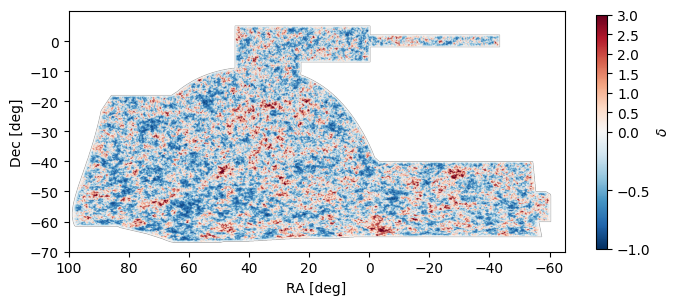

In [4]:
ell = np.arange(L)
cl = (ell + 50.0) ** -2.5
cl *= 0.5 / np.sum((2 * ell + 1) * cl / (4 * np.pi))  # variance of g: 0.5
g = curvedsky.alm2map(curvedsky.rand_alm(cl, lmax=L - 1, seed=1), enmap.zeros(shape, wcs))
delta = np.exp(g - 0.25) - 1

shown = enmap.ndmap(np.where(footprint, delta * taper, np.nan), wcs)
shown = enmap.submap(shown, np.deg2rad([[-70, 100], [10, -65]]))
(dec0, ra0), (dec1, ra1) = np.rad2deg(shown.box())
plt.figure(figsize=(8, 3.8))
plt.imshow(
    shown,
    origin="lower",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(0, vmin=-1, vmax=3),
    extent=[ra0, ra1, dec0, dec1],
)
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.colorbar(label=r"$\delta$", shrink=0.8)
plt.show()

## 3. The scattering transform

The constructor prepares everything that depends only on the geometry. With a mask the
statistics are measured inside it, and `cut=True` keeps only the rings that cross it. With
JAX the first call also compiles the transform.

In [5]:
t0 = time.time()
st = harmonic.CARScatterTransform(shape, wcs, mask=interior, cut=True, backend=BACKEND)
print(f"setup: {time.time() - t0:.1f} s")

for i in range(2):
    t0 = time.time()
    # np.asarray waits for the device to finish, so the time is the whole transform
    mean, var, S1, P00, C01, C11 = [np.asarray(s) for s in st(delta * taper)]
    print(f"call {i + 1}: {time.time() - t0:.1f} s")

print(f"coefficients: S1 {S1.size}, P00 {P00.size}, C01 {C01.size}, C11 {C11.size}")

setup: 0.5 s


call 1: 6.8 s


call 2: 7.3 s
coefficients: S1 50, P00 50, C01 1125, C11 35625
